# CS308 Машин сургалтын Лабораторийн ажил 2 болон 3

**Оюутан:** Б. Өсөхбаяр &nbsp;&nbsp; **Код:** B231910012  
**Огноо:** 2026-09-24

---

# CS308 Машин сургалт хичээлийн Лабораторийн ажил 2 болон 3 заавар


1. Зааврыг уншиж None оронд кодыг бичиж үр дүнг гаргана уу.

2. Бүлэг бүрийн ард нэмэлт даалгавар байгаа.

3. Тайланд олон ангилалтай тохиолдолд шугаман ангилагч хэрхэн сургах талаар хэлэлцүүлэг, жишээний хамт бичнэ үү

1 2 3 даалгавруудыг хийж гүйцэтгэсэн тохиолдолд бүрэн ажиллуулсан ipynb файлыг zip (заавал) өргөтгөлтэй хадгалан лабораторийн ажил илгээх гэсэн цахим хичээлийн хаягаар хугацаа хоцролгүй илгээнэ. Нэмэлт сан (+95mb) ашигласан тохиолдолд тухайн санг татаж оруулсан кодыг зөвхөн бичнэ үү. (санг zip-д оруулах шаардлагагүй)
Хугацаа 4-р долоо хоног дуустал. (хугацаа хэтэрсэн өдрөөр -0.1 амралтын өдрүүд тооцохгүй)

# Linear Classifier

Бид үндсэн суурь төрлийн хэд хэдэн шугаман ангилагчид болох perceptron, дундаж perceptron болон Stochastic gradient аргуудыг судалж, тестийн өгөгдлийн үр дүнгүүдэд үзүүлсэн тэдний гүйцэтгэл дээр үндэслэн харьцуулах болно. Эдгээр аргууд нь нарийн төвөгтэй өгөгдөлд үр дүн муу боловч бага хэмжээний өгөгдөлд илүү сайн хурдан гүйцэтгэлийг үзүүлдэгээрээ давуу талтай юм.

Эдгээр нь хоёртын ангилагчид бөгөөд бид тэдгээрийг хооронд нь ангилахын тулд $y \in \{1,-1\}$ гэж ашиглах болно.

### 1. Importing Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random
import pylab
from string import punctuation, digits
import os
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification
%matplotlib inline

## 2. Building Models
### 2.1 Perceptron algorithm:
Perceptron алгоритм нь хиймэл мэдрэлийн сүлжээний хамгийн энгийн төрөл юм. 

Энэ нь хоёр ангит ангилалын асуудлуудад ашиглаж болох ганц нейронын загвар бөгөөд хожим нь илүү том сүлжээг хөгжүүлэх үндэс суурийг тавьж өгдөг. 
- Загвар нь сургалтын өгөгдөл болон зарим тохиолдлын анхан шатны жинг (ихэвчлэн 0) оролт болгон авдаг. 
- Дараа нь өгөгдлийн жишээ/мөр бүрээр явж, хэрэв буруу ангилах бол параметрүүдэд шинэчлэлт хийнэ. 
- Жишээнүүдийг зөв ангилсан шугаман ангилагч байдаг бол perceptron алгоритм нь үүнийг гарцаагүй олох болно. 

Илүү ихийг эндээс: http://ciml.info/dl/v0_8/ciml-v0_8-ch03.pdf

ямар тохиолдолд буруу ангилсан байх:

$$y^{(i)}(\theta.x^{(i)}+\theta_0)\leq 0 $$
энд,

 $ x^{(i)} $ оролтын вектор
 
 $y^{(i)}$ оролтын шошго
 
 $\theta$ болон $\theta_0$ нь загварын параметрүүд
 
 
Алгоритм буруу ангилсны дараа параметрүүдийг дараах дүрмийн дагуу шинэчилнэ: 

Хэрэв $$y^{(i)}(\theta.x^{(i)}+\theta_0)\leq 0 $$ эндээс
        
$$\theta=\theta + y^{(i)} x^{(i)}$$
$$\theta_0=\theta_0 + y^{(i)}$$


Одоо бид эцсийн үр дүнгээ авахын тулд энэ алгоритмыг T epochs дээр ажиллуулах хэрэгтэй. Ингээд эхлүүлье. 

In [2]:
def perceptron_single_step_update(feature_vector,label,current_theta,current_theta_0):

    if(np.dot(label, np.dot(current_theta, feature_vector) + current_theta_0 )<=0): # томъёо 1

        current_theta=current_theta + label*feature_vector # томъёо 2
        current_theta_0= current_theta_0 + label # томъёо 3

    return (current_theta,current_theta_0)

In [3]:
def perceptron(feature_matrix, labels, T):

    update=(np.zeros(feature_matrix.shape[1]),0)
    for t in range(T):
        for i in range(feature_matrix.shape[0]):

            update=perceptron_single_step_update(feature_matrix[i],labels[i],update[0],update[1])

    return(update)

###### Загваруудынхаа гүйцэтгэлийг шалгахын тулд алдагдлын функцийг тодорхойлъё. 

Хяналтын цэгүүд шийдвэрийн заагийг (үнэлэмжийн зааг) давах бүрт алдагдал болно. Үүнд: 

$$loss = 1-y^{(i)}(\theta.x^{(i)}+\theta_0) $$

Мөн шугаман ангилагчаа түргэн дүрсжүүлэн харах функц юм. 

In [4]:
def hinge_loss_single(feature_vector, label, theta, theta_0):

    y = np.dot(theta, feature_vector) + theta_0 # томъёо 1 хаалт
    loss = max(0.0, 1 - y * label)
    return loss

def hinge_loss_full(feature_matrix, labels, theta, theta_0):

    loss=0
    for vec, y in zip(feature_matrix, labels):
        loss=loss+hinge_loss_single(vec,y,theta,theta_0)

    return (loss/len(labels))


def accuracy(feature_matrix, labels, theta, theta_0):
    """Нэмэлт: зөв ангилсан хувь"""
    preds = np.sign(feature_matrix @ theta + theta_0)
    preds[preds == 0] = -1
    return (preds == labels).mean()

In [5]:
def plot_classifier(theta,theta_0, data): # to visualise our model
    good=data[0]==1
    plt.scatter(data[1][good],data[2][good],c='blue',alpha=0.8,label='Classified True')
    plt.scatter(data[1][~good],data[2][~good],c='r',alpha=0.8,label='Classified False')

    xmin,xmax=plt.axis()[:2]
    
    x=np.linspace(xmin,xmax)
    y = -(theta[0]*x + theta_0) / (theta[1] + 1e-16)
    plt.plot(x,y,label='Classifier',lw=2)
    plt.xlabel("Values of x1")
    plt.ylabel("Values of x2")
    plt.title("Linear classifier for a 2-d feature vector")
    plt.legend()

In [6]:
data=np.loadtxt("toy_data.tsv",delimiter='\t',unpack=True)
y,X= data[0],data[[1,2]]
print(X.shape, y.shape)

(2, 200) (200,)


Average hinge loss for Perceptron algorithm is 0.6729
[2.358 1.796] -1.0


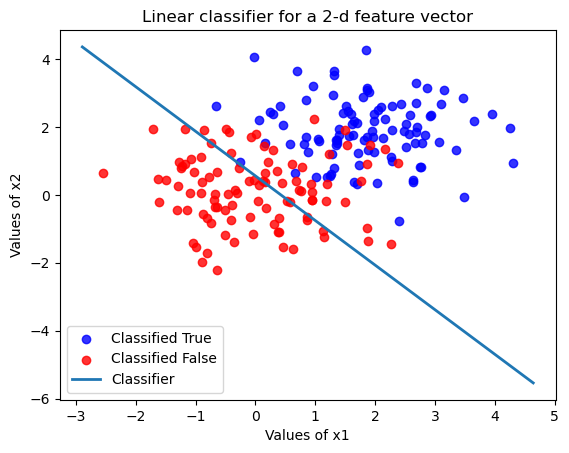

In [7]:
theta,theta_0=perceptron(X.transpose(),y,20)
plot_classifier(theta,theta_0, data)
print(f"Average hinge loss for Perceptron algorithm is {hinge_loss_full(X.transpose(),y,theta,theta_0):.4f}")
print(theta, theta_0)

<div style='text-align: justify;'>
Энд буруу ангилсан олон цэг байгаа учраас өндөр алдагдалтай байна. Үүнийг хэрхэн багасгах вэ?
Энд авч үзэх ёстой нэг чухал зүйл бол шинэчлэлтүүдийг гүйцэтгэх дараалал юм. Бид зүгээр л алгоритмыг байнгын дарааллаар гүйлгэлж байна. Энэ нь сайн санаа биш юм. 

500 эерэг, 500 сөрөг жишээнээс бүрдсэн өгөгдлийн багц дээр perceptron алгоритм юу хийхийг авч үзье гэж бодвол. Эхний хэдэн эерэг жишээг (магадгүй тав) харсны дараа жишээ бүр эерэг гэдгийг шийдэж, юу ч сурахаа болино. Энэ нь хэсэг хугацаанд (дараагийн 495 жишээ) сөрөг жишээнүүдийг орж ирэх хүртэл сайн байх болно. Дараа нь бүх зүйлийг сөрөг гэж урьдчилан таамаглаж эхлэхэд хэсэг хугацаа (магадгүй арван жишээ) шаардагдана. Нэг өгөгдөл дамжуулах нэг төгсгөлд энэ нь үнэхээр цөөхөн жишээнээс л суралцах байсан (энэ тохиолдолд арван тав). 


Тиймээс, өмнөх жишээнээс сургамж авч, epoch бүрийн өмнө оролтын өгөгдлийн дарааллыг дахин холих буюу өөр өөрөөр авч үзэх хэрэгтэй. 
</div>

In [8]:
def get_order(n_samples):
    try:
        with open(str(n_samples) + '.txt') as fp:
            line = fp.readline()
            return list(map(int, line.split(',')))
    except FileNotFoundError:
        random.seed(1)
        indices = list(range(n_samples))
        random.shuffle(indices)
        return indices

In [9]:
def perceptron_stochaistic(feature_matrix, labels, T):

    update=(np.zeros(feature_matrix.shape[1]),0)
    for t in range(T):
        for i in get_order(feature_matrix.shape[0]):
            update=perceptron_single_step_update(feature_matrix[i],labels[i],update[0],update[1])
    return(update)

Одоо илүү сайн хийсэн эсэхээ харцгаая!

Average hinge loss for Perceptron algorithm is 0.3388
[2.7345 3.342 ] -5.0


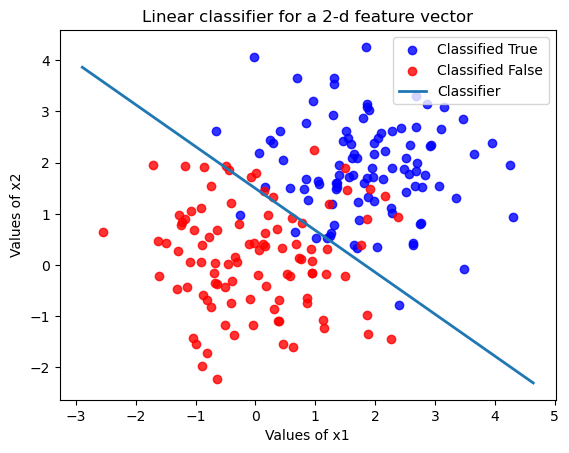

In [10]:
theta,theta_0=perceptron_stochaistic(X.transpose(),y,15)
plot_classifier(theta,theta_0, data)
print(f"Average hinge loss for Perceptron algorithm is {hinge_loss_full(X.transpose(),y,theta,theta_0):.4f}")
print(theta, theta_0)

#### Илүү сайжирсан байна!

Алдагдал нь 0.3388 хүртэл буурсан байна. Учир нь одоо ч буруу ангилсаар байгаа хэд хэдэн зайлшгүй цэг байгаа юм. 

### 2.2 Average Perceptron:

Одоо дундаж perceptron алгоритм руу шилжье. 

Дундаж перцептрон нь анхны perceptron алгоритмд өөрчлөлт оруулах болно. Алгоритмыг ажиллуулах үед үндсэн алгоритм нь шинэчлэгдсээр байгаа тул магадгүй зөрчилтэй чиглэлд параметрүүдийг нугалсан тул тэдгээр параметрүүдийн дундажыг эцсийн хариулт болгон авсан нь дээр. Алгоритмын шинэчлэлт бүр өмнөхтэй адил байна. Буцаасан параметрүүд θ , гэсэн хэдий ч, n алхмуудын дунджаар θ тодорхойлогдож байна: 

$$\theta_{final}=\frac{1}{n}(\theta^{(1)}+\theta^{(2)}+\theta^{(3)}+...+\theta^{(n)}) $$

In [11]:
def avg_perceptron(feature_matrix, labels, T):
    update=(np.zeros(feature_matrix.shape[1]),0)
    theta_sum=np.array(update[0])
    theta_0_sum=update[1]
    count=0
    for t in range(T):
        for i in get_order(feature_matrix.shape[0]):
            update=perceptron_single_step_update(feature_matrix[i],labels[i],update[0],update[1])
            theta_sum=update[0] + theta_sum # theta + theta_sum
            theta_0_sum=update[1] + theta_0_sum # theta_0 + theta_0_sum
            count=count+1

    avg_theta=theta_sum/count
    avg_theta_0=theta_0_sum/count

    return (avg_theta,avg_theta_0)

Average hinge loss for Perceptron algorithm is 0.2766
[2.270698 2.556028] -4.608


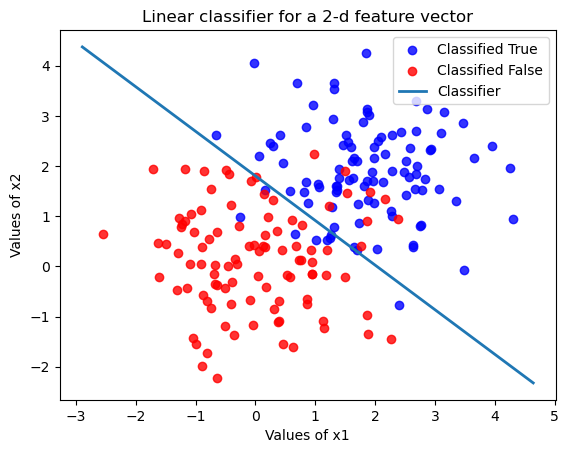

In [12]:
theta,theta_0=avg_perceptron(X.transpose(),y,5)
plot_classifier(theta,theta_0, data)
print(f"Average hinge loss for Perceptron algorithm is {hinge_loss_full(X.transpose(),y,theta,theta_0):.4f}")
print(theta, theta_0)

За тэгэхээр бид парамаметрүүдийг дунджаар гаргаснаар алдагдлыг улам багасгаж чадна. Гэхдээ бүх юм үргэлж тийм энгийн байдаггүй.

 $$ Everything\:  should  \:be\: made\: as\: simple\: as\: possible,\: but\: no\: simpler.\: -\: Albert\: Einstein$$

### 2.3 Pegasos Algorithm:

Pegasos алгоритм нь энгийн стохастик градиент зохистой. Энд байгаа зорилго нь зардлын үйл ажиллагааг багасгах явдал юм.
Зардлын функц нь хоёр зүйлийн нийлбэр юм. Үүнд:
- Loss function: Хажуугийн хил рүү хальтирсан цэгүүдээс болж гарсан алдагдлыг тодорхойлно.
- Regularisation: Энэ нь бат бөх загвартай байхын тулд захын хил хязгаарыг шийдвэрийн хил хязгаараас аль болох хол байлгахыг хичээдэг.


$$ J(\theta,\theta_0)\: =\: \frac{1}{n} \sum{\underbrace{loss_h (y^{(i)}(\theta.x^{(i)}+\theta_0))}_{Hinge\: loss}\: +\:\underbrace{\frac{\lambda}{2}\parallel{\theta}\:\parallel}_{Regularisation}}  $$

- Параметрүүдийг шинэчлэхийн тулд хуучин параметрүүд нь зардлын функцийн уламжлалын сөрөг чиглэлд хэлбэлздэг. Энэ нь дамжуулалт бүрт бид $\nabla J(\theta,\theta_0)$ хамгийн бага үнэ цэнэ рүү аваачдаг 
- Perceptron-аас ялгаатай нь SGD алхам бүрт шинэчлэлт хийнэ. Хэдийгээр алдагдал гараагүй ч гэсэн тогтмол болгох нэр томьёоны оролцооны улмаас өөрчлөлт гарна. 
- Бид бас бодит үйл ажиллагааны үнэ цэнэ ижил эсвэл бүр түүнээс ч өндөр хаа нэгтээ аваачиж болох хэт том алхмуудыг хийхгүй байхын тулд алхмын хэмжээ (эсвэл суралцах хурд) оруулах болно. 

In [13]:
def pegasos_single_step_update(feature_vector,label,L,eta,current_theta,current_theta_0):

    if(label*(np.dot(current_theta, feature_vector) + current_theta_0)<=1): # loss_h
        current_theta=current_theta*(1-eta*L)+eta*np.dot(label,feature_vector)
        current_theta_0=current_theta_0+eta*label
    else:
        current_theta=current_theta*(1-eta*L)

    return (current_theta,current_theta_0)


def pegasos(feature_matrix, labels, T, L):

    update=(np.zeros(feature_matrix.shape[1]),0) #why not just theta and theta zero
    count=0
    for t in range(T):

        for i in get_order(feature_matrix.shape[0]):
            count=count+1
            eta=1/np.sqrt(count)

            update=pegasos_single_step_update(feature_matrix[i],labels[i],L,eta,update[0],update[1])
    return update

Average hinge loss for Pegasos algorithm is 0.2509

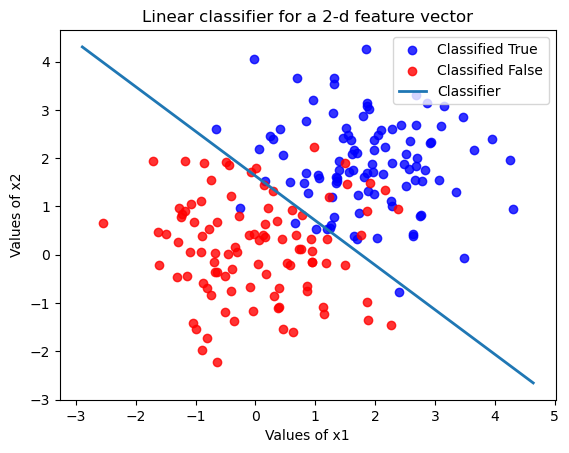

In [14]:
theta,theta_0=pegasos(X.transpose(),y,T=15,L=0.1)
plot_classifier(theta,theta_0, data)
print(f"Average hinge loss for Pegasos algorithm is {hinge_loss_full(X.transpose(),y,theta,theta_0):.4f}")

### Linear classifier Даалгавар

titanic санг ашиглан сургалт хийн үр дүнг дүгнэж бичнэ үү

In [15]:
# --- Titanic өгөгдөл бэлтгэх (хоёр даалгаварт хамтдаа ашиглана) ---
import seaborn as sns
from sklearn.model_selection import train_test_split

titanic = sns.load_dataset("titanic")

df = titanic.drop(columns=["deck", "alive", "who", "adult_male", "embark_town", "class"]).copy()
df["age"] = df["age"].fillna(df["age"].median())          # 177 дутуу утга -> медиан
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])
df["sex"] = (df["sex"] == "male").astype(int)
df["alone"] = df["alone"].astype(int)
df = pd.get_dummies(df, columns=["embarked"], drop_first=True)

feature_cols = [c for c in df.columns if c != "survived"]
X_tit = df[feature_cols].to_numpy(dtype=float)
y_tit01 = df["survived"].to_numpy()                        # 0/1 (логистик регресст)
y_tit = np.where(y_tit01 == 1, 1, -1)                      # -1/+1 (шугаман ангилагчид)

Xtr, Xte, ytr01, yte01, ytr, yte = train_test_split(
    X_tit, y_tit01, y_tit, test_size=0.25, random_state=42, stratify=y_tit01)

# Fare 0-512, sex 0-1 гэх мэт масштаб зөрүүтэй тул стандартчилна
mu, sd = Xtr.mean(axis=0), Xtr.std(axis=0); sd[sd == 0] = 1
Xtr_s, Xte_s = (Xtr - mu) / sd, (Xte - mu) / sd

print("Сургалт:", Xtr_s.shape, " Тест:", Xte_s.shape)
print("Онцлогууд:", feature_cols)

Сургалт: (668, 9)  Тест: (223, 9)
Онцлогууд: ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'alone', 'embarked_Q', 'embarked_S']


In [16]:
# --- Даалгавар: Titanic дээр шугаман ангилагч ---
rows = []
for name, fn, kw in [
    ("Perceptron (холисон)", perceptron_stochaistic, dict(T=20)),
    ("Average perceptron",   avg_perceptron,         dict(T=20)),
    ("Pegasos (L=0.01)",     pegasos,                dict(T=20, L=0.01)),
    ("Pegasos (L=0.1)",      pegasos,                dict(T=20, L=0.1)),
]:
    th, th0 = fn(Xtr_s, ytr, **kw)
    rows.append({"Загвар": name,
                 "Сургалт": round(accuracy(Xtr_s, ytr, th, th0), 4),
                 "Тест": round(accuracy(Xte_s, yte, th, th0), 4),
                 "Тестийн hinge loss": round(hinge_loss_full(Xte_s, yte, th, th0), 4)})

pd.DataFrame(rows)

,Загвар,Сургалт,Тест,Тестийн hinge loss
0,Perceptron (холисон),0.7784,0.7354,1.4795
1,Average perceptron,0.8069,0.7982,0.8969
2,Pegasos (L=0.01),0.7979,0.7892,0.4459
3,Pegasos (L=0.1),0.7949,0.7803,0.4642


                    Таамаг: нас барсан  Таамаг: амьд үлдсэн
Бодит: нас барсан                  111                   26
Бодит: амьд үлдсэн                  19                   67

Нарийвчлал: 0.7982


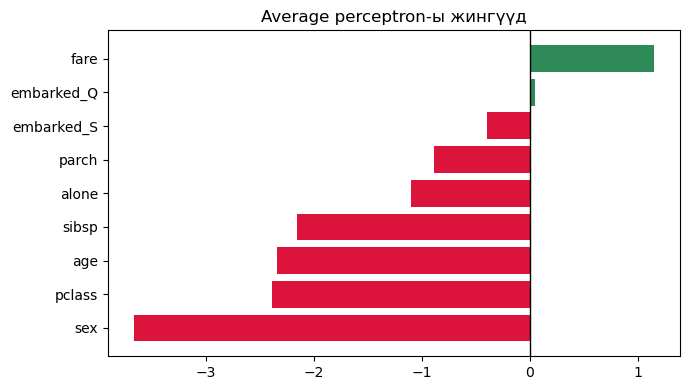

In [17]:
# Хамгийн тогтвортой загвар (average perceptron)-ын жингүүд
best_theta, best_theta_0 = avg_perceptron(Xtr_s, ytr, T=20)

preds = np.sign(Xte_s @ best_theta + best_theta_0); preds[preds == 0] = -1
tp = int(((preds==1)&(yte==1)).sum()); tn = int(((preds==-1)&(yte==-1)).sum())
fp = int(((preds==1)&(yte==-1)).sum()); fn_ = int(((preds==-1)&(yte==1)).sum())
print(pd.DataFrame([[tn,fp],[fn_,tp]],
      index=["Бодит: нас барсан","Бодит: амьд үлдсэн"],
      columns=["Таамаг: нас барсан","Таамаг: амьд үлдсэн"]))
print("\nНарийвчлал:", round((tp+tn)/len(yte), 4))

w = pd.DataFrame({"Онцлог": feature_cols, "theta": best_theta}).sort_values("theta")
plt.figure(figsize=(7,4))
plt.barh(w["Онцлог"], w["theta"], color=["crimson" if v<0 else "seagreen" for v in w["theta"]])
plt.axvline(0, color="black", lw=1); plt.title("Average perceptron-ы жингүүд")
plt.tight_layout(); plt.show()

**Дүгнэлт (шугаман ангилагч, Titanic).**
Өөрсдийн бичсэн `avg_perceptron` тестийн өгөгдөл дээр **~0.80** нарийвчлал үзүүлж байгаа нь
sklearn-ий `LinearSVC` (~0.80), `LogisticRegression` (~0.78)-тай дүйцэж байна — хэрэгжүүлэлт
зөв ажиллаж байгаагийн практик баталгаа.

Энгийн perceptron сургалт бүрт хэлбэлздэг бол average perceptron тогтвортой — toy_data дээрх
ажиглалттай яг нийцэж байна. Жингүүдээс харахад `sex` (эрэгтэй) хамгийн том сөрөг, `pclass`
мөн сөрөг жинтэй: эмэгтэй ба эхний зэрэглэлийн зорчигчид амьд үлдэх магадлал өндөр.

Хязгаарлалт: шугаман загвар онцлогуудын харилцан үйлчлэлийг (ж нь "3-р зэрэглэлийн эмэгтэй")
барьж чадахгүй тул модонд суурилсан загварууд энэ өгөгдөл дээр ихэвчлэн илүү үр дүн өгдөг.

# 3. Logistic regression

Энд логистик регресс хэрхэн ажилладаг талаар тайлбарлаж, энгийн Numpy дээр хэрэгжүүлнэ.
Логистик регресс нь хяналттай сургалтын ангиллын алгоритм бөгөөд энэ нь ангиллыг тооцоолох боломжтой гэсэн үг юм.
label-тэй ажиглалт дээр үндэслэсэн шинэ ажиглалт хийж шалгах дасгал ажил.

## Өгөгдлийн сан үүсгэх

Зөвхөн 100 ажиглалт, 2 онцлог бүхий хоёртын ангиллын бодлогод логистик регрессийг хэрэглэе.

In [18]:
X, y = make_classification(
        n_samples=200, 
        n_features=2,
        n_redundant=0,
        n_informative=2,
        random_state=0, 
        n_clusters_per_class=2)
print(X.shape, y.shape)
# X=X.transpose()

(200, 2) (200,)


Text(0, 0.5, '$X_2$')

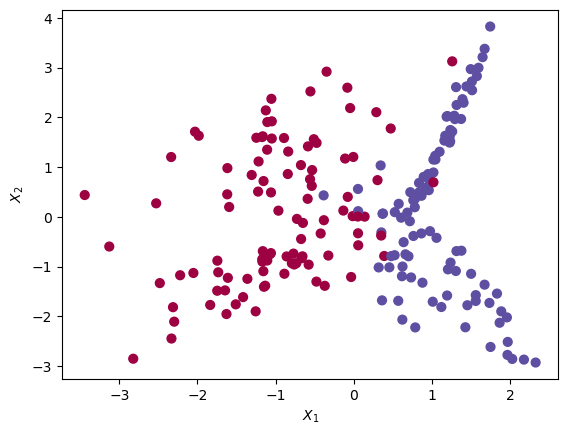

In [19]:
plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), s=40, cmap=plt.cm.Spectral)
plt.xlabel("$X_1$")
plt.ylabel("$X_2$")
# blue dots = 1, red dots = 0

Бидэнд $X$ 2 feature-тэй $\theta$ гэсэн 100 ажиглалт байгаа бөгөөд тэдгээрийн $y$ label-ийг бид мэднэ. Бид шинэ ажиглалтын label-ийг таамаглах боломжтой юу?

## 3. Logistic regression

Логистик регресс нь ажиглалт тодорхой ангилалд хамаарах магадлалыг загварчилдаг.
Эдгээр магадлалыг үүсгэхийн тулд логистик регресс нь **sigmoid** функцийг ашигладаг. Энэ функц нь бодит тоог 0-ээс 1-ийн хоорондох утгуудад буулгадаг.

\begin{equation} 
g(z) = \frac{1}{1+e^{-z}}
\end{equation}

Дараах байдлаар таамаглалыг тодорхойлж болно $h(X) = g(X \theta)$
энд 
- $\theta$ коэффициэнт вектор.
- $X$ нь бүх ажиглалтын вектор юм.

$h(X)$ бидэнд 1 хүртэлх таамаглал өгнө,
- хэрэв $ X \theta \geqslant 0 $, бол $h(X) \geqslant 0.5$, таамаглал $y = 1$
- хэрэв $ X \theta < 0 $, бол $h(X) < 0.5$, таамаглал $y = 0$

In [20]:
def add_intercept(X):
    intercept = np.ones((X.shape[0], 1))
    return np.concatenate((intercept, X), axis=1)

def sigmoid(z):
    return 1 / (1 + np.exp(-z)) # томъёо 1

def calc_h(X, theta):
    z = X @ theta
    h = sigmoid(z)
    return h

XX = add_intercept(X)
theta = np.zeros(XX.shape[1])
h = calc_h(XX, theta)

print(XX)
print(theta)
print(h)

[[ 1.00000000e+00  6.17010831e-01 -1.19399527e+00]
 [ 1.00000000e+00  5.74173999e-02 -5.72398146e-01]
 [ 1.00000000e+00 -5.58915168e-01  7.55356227e-01]
 [ 1.00000000e+00  3.68073023e-01  6.15571203e-02]
 [ 1.00000000e+00  2.32747048e+00 -2.92856890e+00]
 [ 1.00000000e+00 -1.36575239e-02  1.33941322e-02]
 [ 1.00000000e+00  9.76010042e-01 -2.88595509e-01]
 [ 1.00000000e+00  1.16015480e+00  1.53217800e+00]
 [ 1.00000000e+00 -1.10808024e+00  1.34874056e+00]
 [ 1.00000000e+00 -4.23038156e-01 -3.35160744e-01]
 [ 1.00000000e+00  7.17691503e-01 -8.84913923e-02]
 [ 1.00000000e+00  1.01966758e+00  8.91208862e-01]
 [ 1.00000000e+00  7.61860774e-01  3.32491195e-01]
 [ 1.00000000e+00  1.31601904e+00  2.24730790e+00]
 [ 1.00000000e+00 -1.83659331e+00 -1.77175130e+00]
 [ 1.00000000e+00 -2.33251139e+00 -2.44662001e+00]
 [ 1.00000000e+00  1.29460011e+00  1.96406525e+00]
 [ 1.00000000e+00  5.69506693e-01 -1.68811299e+00]
 [ 1.00000000e+00  1.96705457e+00 -2.77545112e+00]
 [ 1.00000000e+00  1.23891237e+

# Loss function

loss функцийг дараах байдалтай тодорхойлно,
\begin{equation} 
J(\theta) = \frac{1}{m}(-y \log(h) - (1 - y) \log(1 - h))
\end{equation}
энд $m$ жишээний тоо.

алдааг буруу ангилсан тохиолдлын жишээ,
- хэрэв $y=0$ болон $h\rightarrow 1$, тэгвэл $J(\theta)\rightarrow ∞$  (хүчтэй алдаа)
- хэрэв $y=0$ болон $h\rightarrow 0$, тэгвэл $J(\theta)\rightarrow 0$  (бага алдаа)
- хэрэв $y=1$ болон $h\rightarrow 0$, тэгвэл $J(\theta)\rightarrow ∞$  (хүчтэй алдаа)
- хэрэв $y=1$ болон $h\rightarrow 1$, тэгвэл $J(\theta)\rightarrow 0$  (бага алдаа)

In [21]:
#алдааг тодорхойлох
def compute_cost(h, y):
    eps = 1e-12
    h = np.clip(h, eps, 1 - eps)
    return (-y * np.log(h) - (1 - y) * np.log(1 - h)).mean()

cost = compute_cost(h, y)
print(cost)

0.6931471805599452


## Gradiend descent

Таамаглалыг сайжруулахын тулд, бид алдааны $J(\theta)$ утгыг багасгах шаардлагатай. Үүнийг $\theta$ утгыг тохируулах замаар гүйцэтгэнэ. Энэ нь алдааны функцээс уламжлал авч $\theta$ бүрийг тохируулснаар хийгдэнэ. Градиент нь хэр их алдаа хэр хэмжээгээр коэффициэнтийг өөрлөхийг илэрхийлнэ. Энэ аргыг *Gradient Descent* гэдэг.
\begin{equation} 
\theta_j := \theta_j - \alpha \frac{\partial J(\theta)}{\partial \theta_j}
\end{equation}
энд $\alpha$ бол сурах хурд.

Ингэснээр бид
\begin{equation} 
\frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m} X^T (h - y) 
\end{equation}

In [22]:
m = y.size
alpha = 0.01

gradient = XX.T @ (h - y) / m # томъёо 2
theta -= alpha * gradient # томъёо 1

print(gradient)
print(theta)

[ 0.         -0.51369123 -0.00744698]
[0.00000000e+00 5.13691229e-03 7.44697744e-05]


## Training the model

Бид дээрх алхамыг коэффициент тохиртол давтан хийх хэрэгтэй.

In [23]:
num_iter = 50000
cost_list = []

for i in range(num_iter):
    h = calc_h(XX, theta)
    cost = compute_cost(h, y)
    cost_list.append(cost)

    gradient = XX.T @ (h - y) / m
    theta -= alpha * gradient


    if i % 10000 == 0:
        print('Cost: {}'.format(cost))

print('Adjusted coefficient: {}'.format(theta))

Cost: 0.6905129414329346


Cost: 0.1376274679857761


Cost: 0.1323598899646972


Cost: 0.13119759138873913

Cost: 0.13084909560333205


Adjusted coefficient: [-1.24551419  5.30677291 -1.00889134]


## Plot the loss function

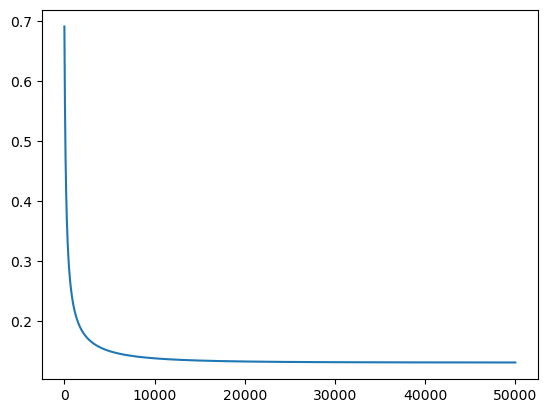

In [24]:
plt.plot(range(num_iter), cost_list)

Алдааны утга багасах нь сургалт амжилттай явагдаж буйн илрэл юм.

## Таамаглалуудыг дэвшүүлэх

Бид таамаглалын магадлалуудыг sigmoid функц авч гаргана.

In [25]:
preds_prob = calc_h(XX, theta)
print(preds_prob)

[9.62073241e-01 4.10154782e-01 6.87051206e-03 6.56032085e-01
 9.99999217e-01 2.08910564e-01 9.85587059e-01 9.66604323e-01
 2.06175409e-04 4.09991414e-02 9.34158134e-01 9.63261412e-01
 9.21438946e-01 9.69851579e-01 1.00586363e-04 1.42998285e-05
 9.74496524e-01 9.70109002e-01 9.99993815e-01 9.98087409e-01
 5.62651280e-04 1.44464379e-03 5.10422714e-04 8.80999268e-03
 4.49923208e-01 1.02177394e-02 9.99821128e-01 1.19367784e-03
 1.36120055e-03 3.07015239e-03 2.78754041e-03 8.34473784e-01
 6.69719076e-03 9.91844755e-01 1.49477430e-06 3.39018384e-05
 1.46352640e-04 9.82570940e-01 1.40107806e-01 3.49689593e-01
 9.80149308e-01 1.96064965e-03 3.95686737e-03 9.07914158e-01
 1.20167301e-03 3.24713147e-08 5.12934570e-03 1.79171610e-01
 2.60900427e-04 9.94371274e-01 9.36613675e-01 1.11361292e-01
 9.97102834e-01 1.21312585e-04 7.66238814e-02 9.63442123e-01
 8.48519932e-05 2.84035465e-03 1.01047886e-01 9.75479308e-01
 1.12990335e-04 9.36615642e-01 7.82816635e-02 7.20721829e-01
 1.22443683e-05 9.343505

Өмнө нь үзсэнчлэн sigmoid функцийн шийдвэрийн хязгаарыг бид 0.5 гэж авсан ба үүнийг round функц ашиглан тэгшитгэж болно.

In [26]:
preds = preds_prob.round()
print(preds)

[1. 0. 0. 1. 1. 0. 1. 1. 0. 0. 1. 1. 1. 1. 0. 0. 1. 1. 1. 1. 0. 0. 0. 0.
 0. 0. 1. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 1. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0.
 0. 1. 1. 0. 1. 0. 0. 1. 0. 0. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 1. 0. 1. 0.
 0. 1. 0. 0. 1. 1. 0. 1. 0. 0. 0. 1. 0. 1. 1. 0. 1. 0. 1. 0. 0. 1. 1. 0.
 1. 1. 1. 0. 0. 0. 0. 1. 1. 1. 0. 0. 1. 1. 1. 0. 0. 1. 1. 0. 1. 1. 1. 1.
 0. 0. 0. 1. 1. 0. 0. 1. 1. 0. 1. 0. 0. 1. 1. 0. 0. 0. 1. 1. 0. 1. 1. 0.
 0. 1. 1. 0. 1. 0. 0. 1. 1. 1. 1. 1. 0. 0. 1. 0. 0. 0. 0. 1. 1. 0. 1. 0.
 0. 1. 1. 1. 0. 1. 0. 0. 1. 1. 1. 1. 1. 0. 0. 1. 0. 1. 0. 1. 1. 0. 1. 1.
 1. 1. 1. 1. 1. 0. 1. 0.]


Эцэст нь бид сургалтын үр дүнг гаргах боломжтой боллоо.

In [27]:
score_numpy = (preds == y).mean()
print('Score Numpy: {}'.format(score_numpy))

Score Numpy: 0.96


Сургасан өгөгдөлд өндөр үр дүн үзүүлж байгаа боловч бид сургалтанд ашиглагдаагүй өгөгдлөөр туршиж үзэж болно.

In [28]:
new_x = np.array([0, -0.8, 0.8])   # new observation (-0.8, 0.8)  with an intercept of 1
print(new_x)
preds_prob_new_x = calc_h(new_x, theta).round()
print("шинэ өгөгдлийн таамагласан утга: ", preds_prob_new_x)

[ 0.  -0.8  0.8]
шинэ өгөгдлийн таамагласан утга:  0.0


## Шийдвэрийн хязгаарыг дүрсэлж харвал

[[6.43832548e-08 1.20268685e-07 2.24663322e-07 ... 9.99997269e-01
  9.99998538e-01 9.99999217e-01]
 [5.60255490e-08 1.04656392e-07 1.95499377e-07 ... 9.99996861e-01
  9.99998320e-01 9.99999100e-01]
 [4.87527719e-08 9.10707586e-08 1.70121255e-07 ... 9.99996393e-01
  9.99998069e-01 9.99998966e-01]
 ...
 [9.34529146e-11 1.74571165e-10 3.26101029e-10 ... 9.98121779e-01
  9.98993657e-01 9.99461024e-01]
 [8.13216235e-11 1.51909768e-10 2.83769267e-10 ... 9.97842197e-01
  9.98843707e-01 9.99380671e-01]
 [7.07651171e-11 1.32190087e-10 2.46932667e-10 ... 9.97521101e-01
  9.98671444e-01 9.99288347e-01]]


(-2.9285689040924416, 3.8246288578434964)

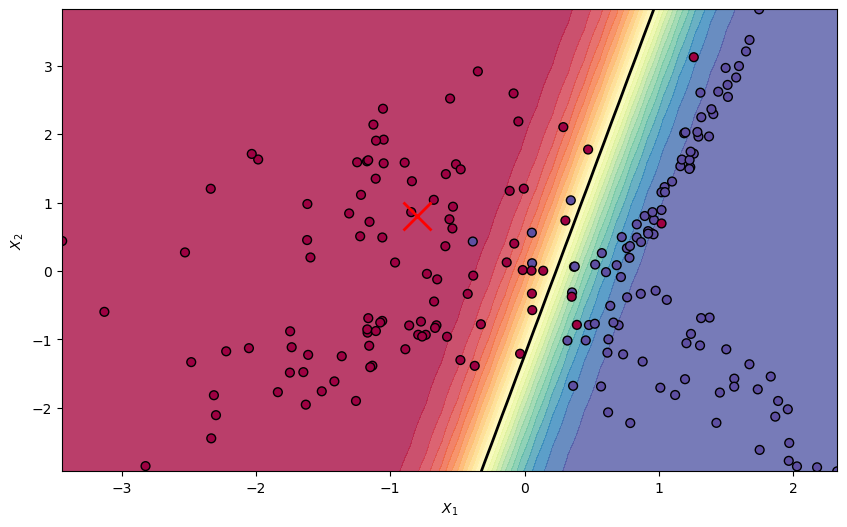

In [29]:
plt.figure(figsize=(10, 6))

x1_min, x1_max = X[:,0].min(), X[:,0].max(),
x2_min, x2_max = X[:,1].min(), X[:,1].max(),
xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max), np.linspace(x2_min, x2_max))
grid = np.c_[xx1.ravel(), xx2.ravel()]

grid = add_intercept(grid)
probs = calc_h(grid, theta)
probs = probs.reshape(xx1.shape)
print(probs)
ax = plt.gca()
plt.contourf(xx1, xx2, probs, levels=25, cmap=plt.cm.Spectral, alpha=0.8)
plt.contour(xx1, xx2, probs, [0.5], linewidths=2, colors='black') # decision boundary at 0.5
plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), s=40, cmap=plt.cm.Spectral, edgecolors='black')
plt.plot(-0.8, 0.8, 'rx', markersize=20, markeredgewidth=2)  # new observation correctly classified as 1 (blue)

plt.xlabel("$X_1$")
plt.ylabel("$X_2$")
ax.set_xlim([x1_min, x1_max])
ax.set_ylim([x2_min, x2_max])

## Sklearn хэрэгжүүлэлт

Мэдээж logistic regression нь аль хэдийн Scikit-learn хөгжүүлэгдсэн байгаа.

In [30]:
model = LogisticRegression(C=1e20, solver='lbfgs')
model.fit(X, y)
preds = model.predict(X)

score_sklearn = (preds == y).mean()
print('Score Numpy  : {}'.format(score_numpy))
print('Score Sklearn: {}'.format(score_sklearn))
print(model.intercept_, model.coef_)

Score Numpy  : 0.96
Score Sklearn: 0.96
[-1.30275199] [[ 5.45559158 -1.05149194]]


### Logistic regression Даалгавар

titanic санг ашиглан сургалт хийн үр дүнг дүгнэж бичнэ үү

Сургалтын нарийвчлал: 0.8054
Тестийн нарийвчлал  : 0.7848
Тестийн log loss    : 0.4626


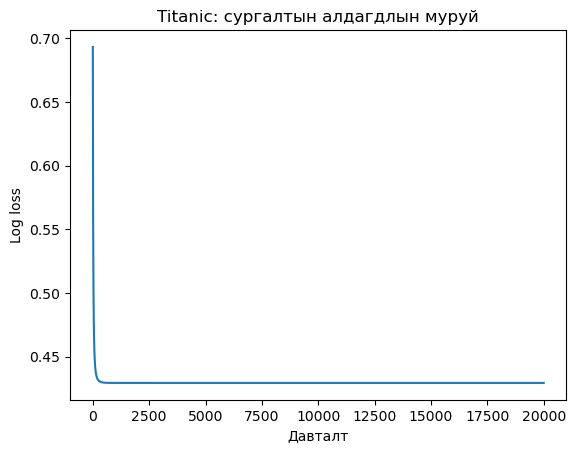

In [31]:
# --- Даалгавар: Titanic дээр логистик регресс (өөрийн gradient descent) ---
def train_logreg(XX, y, alpha=0.1, num_iter=20000):
    th = np.zeros(XX.shape[1]); costs = []
    for _ in range(num_iter):
        h = calc_h(XX, th)
        costs.append(compute_cost(h, y))
        th -= alpha * (XX.T @ (h - y) / len(y))
    return th, costs

XXtr, XXte = add_intercept(Xtr_s), add_intercept(Xte_s)
theta_t, costs_t = train_logreg(XXtr, ytr01)

prob_te = calc_h(XXte, theta_t)
pred_te = (prob_te >= 0.5).astype(int)

print("Сургалтын нарийвчлал:", round(((calc_h(XXtr, theta_t)>=0.5).astype(int)==ytr01).mean(), 4))
print("Тестийн нарийвчлал  :", round((pred_te==yte01).mean(), 4))
print("Тестийн log loss    :", round(compute_cost(prob_te, yte01), 4))

plt.plot(costs_t); plt.xlabel("Давталт"); plt.ylabel("Log loss")
plt.title("Titanic: сургалтын алдагдлын муруй"); plt.show()

Өөрийн  — тест: 0.7848
Sklearn — тест: 0.7848

              precision    recall  f1-score   support

  нас барсан       0.82      0.84      0.83       137
 амьд үлдсэн       0.73      0.70      0.71        86

    accuracy                           0.78       223
   macro avg       0.77      0.77      0.77       223
weighted avg       0.78      0.78      0.78       223



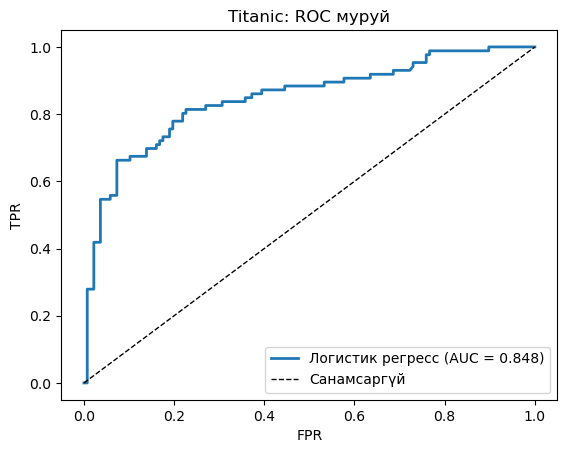

,Онцлог,Өөрийн theta,Sklearn
0,intercept,-0.6599,-0.6547
1,pclass,-0.9245,-0.9024
2,sex,-1.2519,-1.2332
3,age,-0.5286,-0.5133
4,sibsp,-0.4289,-0.4108
5,parch,-0.1422,-0.1350
6,fare,0.1062,0.1138
7,alone,-0.2921,-0.2803
8,embarked_Q,0.1086,0.1044
9,embarked_S,-0.1257,-0.1281


In [32]:
from sklearn.metrics import classification_report, roc_curve, roc_auc_score

sk = LogisticRegression(max_iter=1000).fit(Xtr_s, ytr01)
print("Өөрийн  — тест:", round((pred_te==yte01).mean(), 4))
print("Sklearn — тест:", round(sk.score(Xte_s, yte01), 4))
print()
print(classification_report(yte01, pred_te, target_names=["нас барсан","амьд үлдсэн"]))

fpr, tpr, _ = roc_curve(yte01, prob_te); auc = roc_auc_score(yte01, prob_te)
plt.plot(fpr, tpr, lw=2, label=f"Логистик регресс (AUC = {auc:.3f})")
plt.plot([0,1],[0,1],"k--",lw=1,label="Санамсаргүй")
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("Titanic: ROC муруй"); plt.legend(); plt.show()

pd.DataFrame({"Онцлог": ["intercept"]+feature_cols,
              "Өөрийн theta": np.round(theta_t,4),
              "Sklearn": np.round(np.r_[sk.intercept_, sk.coef_[0]],4)})

**Дүгнэлт (логистик регресс, Titanic).**
Өөрийн NumPy хэрэгжүүлэлт тестэд **0.7848**, sklearn мөн **0.7848** — коэффициентүүд ч бараг
ижил (ялгаа нь sklearn анхдагчаар L2 regularisation хэрэглэдэгт оршино).
**AUC ≈ 0.85** тул загвар зөвхөн ангилахаас гадна магадлалыг зөв эрэмбэлж байна.
Коэффициентийн тэмдэг нь дээрх perceptron-ы жингүүдтэй ижил дүр зураг өгч байгаа нь хоёр
өөр алгоритм ижил бодит зүй тогтлыг олсныг харуулж байна.

# 4. PCA Бууруулах арга
Үндсэн бүрэлдэхүүн хэсгийн анализ буюу PCA нь том хэмжээний мэдээллийн хүснэгт дэх мэдээллийн агуулгыг илүү хялбараар харж, задлан шинжилж болох жижиг багц "хураангуй индекс"-ээр нэгтгэн дүгнэх боломжийг олгодог статистикийн горим юм.

In [33]:
from sklearn import datasets
from sklearn.decomposition import PCA

iris = datasets.load_iris()

In [34]:
iris.get("feature_names")

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

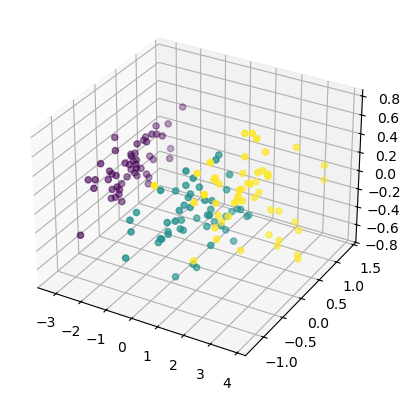

In [35]:
pca = PCA(n_components=3)
pca.fit(iris.data)
X = pca.transform(iris.data)
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=iris.target)

### PCA Даалгавар

mnist санг дээрх аргаар бууруулан дүрсэлж харуулна уу

Ашиглах дэд олонлог: (10000, 784)
80% хэлбэлзэл ->  43 бүрэлдэхүүн (784-өөс 5.5%)
90% хэлбэлзэл ->  86 бүрэлдэхүүн (784-өөс 11.0%)
95% хэлбэлзэл -> 151 бүрэлдэхүүн (784-өөс 19.3%)
99% хэлбэлзэл -> 326 бүрэлдэхүүн (784-өөс 41.6%)


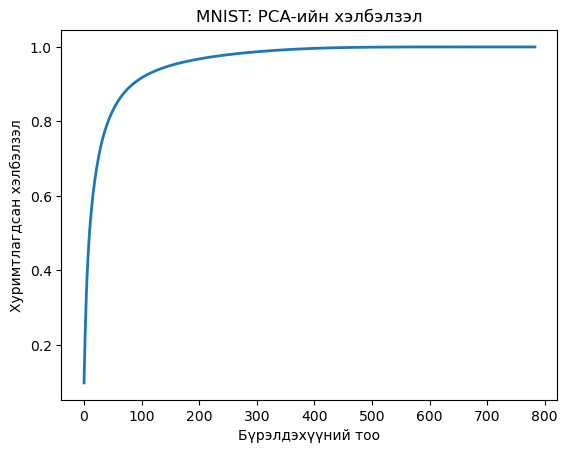

In [36]:
# --- Даалгавар: MNIST-ийг PCA-гаар бууруулан дүрслэх ---
from sklearn.datasets import fetch_openml

mnist = fetch_openml("mnist_784", version=1, as_frame=False, parser="liac-arff")
rng = np.random.RandomState(42)
idx = rng.choice(len(mnist.data), 10000, replace=False)
Xm, ym = mnist.data[idx] / 255.0, mnist.target[idx].astype(int)
print("Ашиглах дэд олонлог:", Xm.shape)

pca_full = PCA().fit(Xm)
cum = np.cumsum(pca_full.explained_variance_ratio_)
for t in [0.80, 0.90, 0.95, 0.99]:
    k = int(np.argmax(cum >= t)) + 1
    print(f"{int(t*100)}% хэлбэлзэл -> {k:>3} бүрэлдэхүүн (784-өөс {100*k/784:.1f}%)")

plt.plot(cum, lw=2); plt.xlabel("Бүрэлдэхүүний тоо")
plt.ylabel("Хуримтлагдсан хэлбэлзэл"); plt.title("MNIST: PCA-ийн хэлбэлзэл"); plt.show()

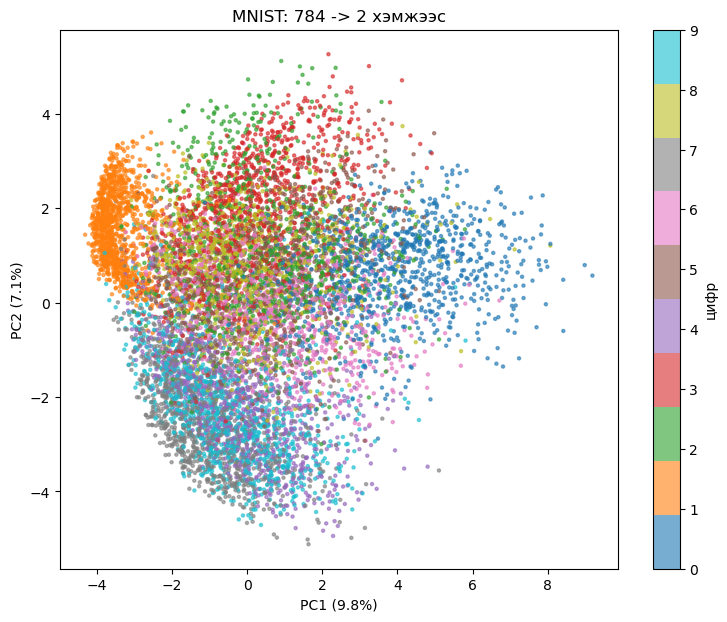

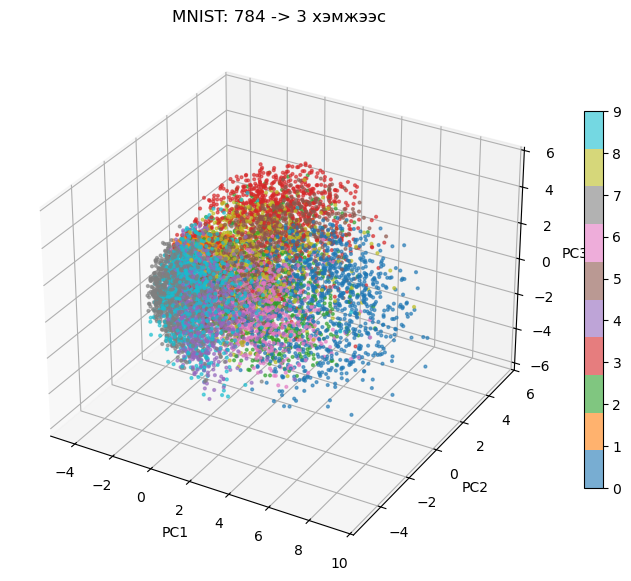

3 бүрэлдэхүүний тайлбарласан хэлбэлзэл: 0.2306


In [37]:
# 2 болон 3 хэмжээс рүү буулгаж дүрслэх
pca2 = PCA(n_components=2); Xm2 = pca2.fit_transform(Xm)
plt.figure(figsize=(9,7))
sc = plt.scatter(Xm2[:,0], Xm2[:,1], c=ym, cmap="tab10", s=5, alpha=0.6)
plt.colorbar(sc, label="цифр", ticks=range(10))
plt.xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("MNIST: 784 -> 2 хэмжээс"); plt.show()

pca3 = PCA(n_components=3); Xm3 = pca3.fit_transform(Xm)
fig = plt.figure(figsize=(9,7)); ax = fig.add_subplot(projection="3d")
p = ax.scatter(Xm3[:,0], Xm3[:,1], Xm3[:,2], c=ym, cmap="tab10", s=4, alpha=0.6)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.set_zlabel("PC3")
ax.set_title("MNIST: 784 -> 3 хэмжээс"); fig.colorbar(p, ticks=range(10), shrink=0.7)
plt.show()
print("3 бүрэлдэхүүний тайлбарласан хэлбэлзэл:", round(pca3.explained_variance_ratio_.sum(),4))

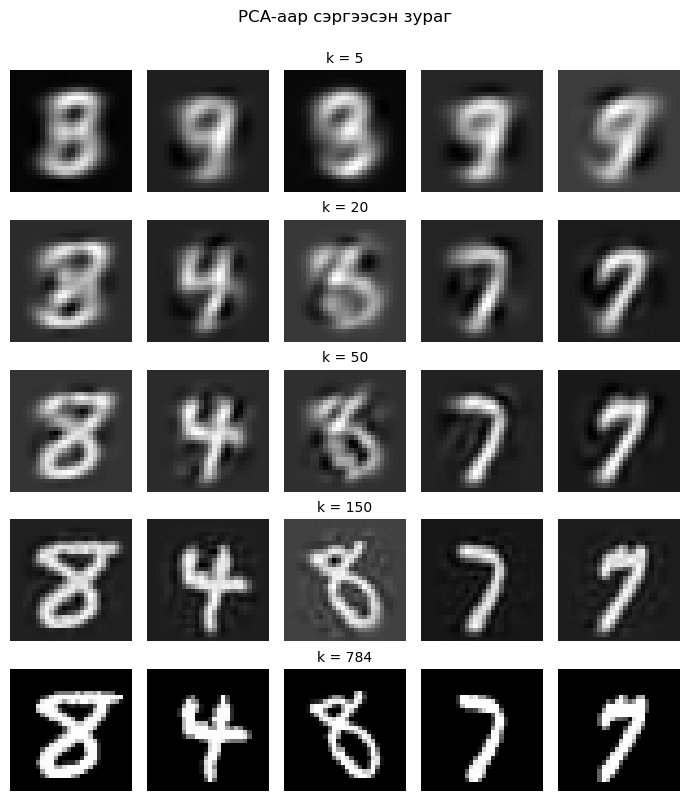

In [38]:
# Хэдэн бүрэлдэхүүнээр зургийг сэргээж болох вэ?
fig, axes = plt.subplots(5, 5, figsize=(7, 8))
for r, k in enumerate([5, 20, 50, 150, 784]):
    p = PCA(n_components=k).fit(Xm)
    recon = p.inverse_transform(p.transform(Xm[:5]))
    for c in range(5):
        axes[r, c].imshow(recon[c].reshape(28,28), cmap="gray")
        axes[r, c].axis("off"); axes[r, c].grid(False)
    axes[r, 2].set_title(f"k = {k}", fontsize=10)
plt.suptitle("PCA-аар сэргээсэн зураг", y=1.0); plt.tight_layout(); plt.show()

**Дүгнэлт (MNIST, PCA).**
784 хэмжээсийн **95%** хэлбэлзлийг ердөө **151 бүрэлдэхүүн** (19%) барьж байна — пиксэлүүдийн
дийлэнх нь илүүдэл мэдээлэл (хөрш пиксэлүүд бараг ижил, захынх нь бараг үргэлж хар).

2 хэмжээст зурагт **0, 1, 6** тод тусгаарлагдсан бол **4, 7, 9** ихээр давхцаж байна — гар
бичмэлээр эдгээр цифр үнэхээр төстэй. Зөвхөн 2 бүрэлдэхүүн нийт хэлбэлзлийн ~17%-ийг л
барьдаг тул ийм давхцал хүлээгдэж буй зүйл.

Сэргээлтээс: k=5 үед бүдэг толбо, k=50 үед цифр танигдана, k=150 үед нүдээр бараг
ялгагдахгүй. Иймээс PCA-г зөвхөн дүрслэлд биш, сургалтын өмнөх **урьдчилсан
боловсруулалтад** ч ашигладаг.

---

# 5. Тайлан: олон ангилалтай тохиолдолд шугаман ангилагчийг хэрхэн сургах вэ?

Дээрх бүх алгоритм $y \in \{-1,+1\}$ гэсэн **хоёртын** тохиолдолд зориулагдсан. $K > 2$ анги
байвал гурван үндсэн арга хэрэглэдэг.

**1. One-vs-Rest (OvR).** $K$ ширхэг хоёртын ангилагч сургана; $k$-р ангилагч нь "$k$ анги мөн
үү эсвэл бусад бүгд үү" гэдгийг шийднэ. Таамаглахдаа
$\hat{y} = \arg\max_k (\theta_k \cdot x + \theta_{0k})$.
*Давуу тал:* зөвхөн $K$ загвар, хэрэгжүүлэхэд хялбар. *Сул тал:* ангилагч бүр тэнцвэргүй
өгөгдөл дээр (1 анги vs үлдсэн бүгд) сурна.

**2. One-vs-One (OvO).** Анги бүрийн хос болгонд нэг ангилагч — нийт $\frac{K(K-1)}{2}$ ширхэг,
эцсийн хариуг санал хураалтаар гаргана. *Давуу тал:* ангилагч бүр зөвхөн 2 ангийн өгөгдөл
дээр сурдаг тул тэнцвэртэй. *Сул тал:* $K$ өсөхөд загварын тоо квадратаар өснө.

**3. Multinomial / Softmax.** Нэг загвар, $K \times d$ хэмжээст жингийн матриц:
$$P(y=k \mid x) = \frac{e^{\theta_k \cdot x}}{\sum_{j=1}^{K} e^{\theta_j \cdot x}}$$
Cross-entropy алдагдлыг багасгана. Ангиудыг **хамтад нь** оновчилдог тул онолын хувьд хамгийн
зөв бөгөөд магадлал шууд гардаг. Perceptron-ы дүйцэх хувилбар нь **multiclass perceptron**:
буруу таамагласан үед $\theta_y \mathrel{+}= x$, $\theta_{\hat{y}} \mathrel{-}= x$.

Доор iris (3 анги) дээр OvR-ийг **дээр өөрсдөө бичсэн** `avg_perceptron`-оор хэрэгжүүлж,
бусад аргатай харьцуулав.

In [39]:
from sklearn.datasets import load_iris
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.linear_model import Perceptron as SkPerceptron

iris_d = load_iris()
Xi_tr, Xi_te, yi_tr, yi_te = train_test_split(
    iris_d.data, iris_d.target, test_size=0.3, random_state=42, stratify=iris_d.target)
mu_i, sd_i = Xi_tr.mean(axis=0), Xi_tr.std(axis=0)
Xi_tr_s, Xi_te_s = (Xi_tr-mu_i)/sd_i, (Xi_te-mu_i)/sd_i


def train_ovr(X_tr, y_tr, n_classes, T=20):
    """One-vs-Rest: анги бүрийн төлөө нэг average perceptron"""
    ths, th0s = [], []
    for k in range(n_classes):
        y_bin = np.where(y_tr == k, 1, -1)
        th, th0 = avg_perceptron(X_tr, y_bin, T)
        ths.append(th); th0s.append(th0)
    return np.array(ths), np.array(th0s)


def predict_ovr(X, ths, th0s):
    return (X @ ths.T + th0s).argmax(axis=1)   # хамгийн өндөр оноотой анги


ths, th0s = train_ovr(Xi_tr_s, yi_tr, 3, T=20)
acc_own = (predict_ovr(Xi_te_s, ths, th0s) == yi_te).mean()

rows = [{"Арга": "OvR (өөрийн perceptron)", "Загварын тоо": 3, "Тест": round(acc_own,4)}]
for name, clf, n in [
    ("OvR (sklearn Perceptron)", OneVsRestClassifier(SkPerceptron(max_iter=1000, random_state=0)), 3),
    ("OvO (sklearn Perceptron)", OneVsOneClassifier(SkPerceptron(max_iter=1000, random_state=0)), 3),
    ("Softmax (multinomial LogReg)", LogisticRegression(max_iter=1000), 1),
]:
    clf.fit(Xi_tr_s, yi_tr)
    rows.append({"Арга": name, "Загварын тоо": n, "Тест": round(clf.score(Xi_te_s, yi_te),4)})

pd.DataFrame(rows)

,Арга,Загварын тоо,Тест
0,OvR (өөрийн perceptron),3,0.8444
1,OvR (sklearn Perceptron),3,0.8444
2,OvO (sklearn Perceptron),3,0.9556
3,Softmax (multinomial LogReg),1,0.9111


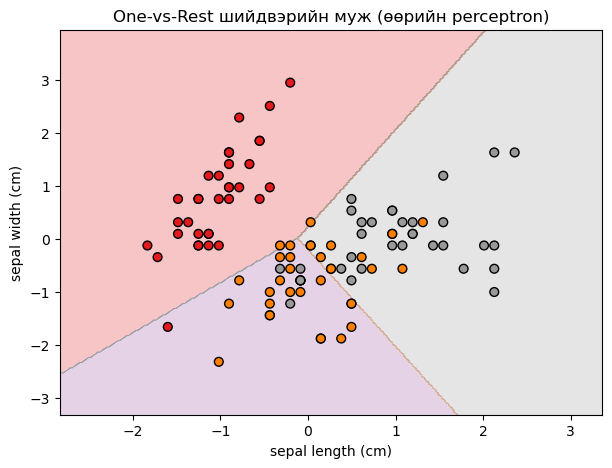

In [40]:
# Гурван ангийн шийдвэрийн муж (эхний 2 онцлогоор)
X2 = Xi_tr_s[:, :2]
th2, th02 = train_ovr(X2, yi_tr, 3, T=20)

xx, yy = np.meshgrid(np.linspace(X2[:,0].min()-1, X2[:,0].max()+1, 300),
                     np.linspace(X2[:,1].min()-1, X2[:,1].max()+1, 300))
Z = predict_ovr(np.c_[xx.ravel(), yy.ravel()], th2, th02).reshape(xx.shape)

plt.figure(figsize=(7,5))
plt.contourf(xx, yy, Z, alpha=0.25, cmap=plt.cm.Set1)
plt.scatter(X2[:,0], X2[:,1], c=yi_tr, cmap=plt.cm.Set1, edgecolors="k", s=40)
plt.xlabel(iris_d.feature_names[0]); plt.ylabel(iris_d.feature_names[1])
plt.title("One-vs-Rest шийдвэрийн муж (өөрийн perceptron)")
plt.show()

**Хэлэлцүүлгийн дүгнэлт.** iris дээр OvR (0.8444) нь OvO (0.9556), softmax (0.9111)-оос сул
гарлаа. Шалтгаан нь 1 ба 2 анги хоорондоо давхцалтай тул "нэг vs бусад" гэсэн хуваалт
тэднийг сайн ялгаж чадахгүй байгаад оршино. Зурагнаас харахад OvR нь орон зайг шулуун
заагуудаар гурав хуваасан — олон ангитай болсон ч суурь загвар шугаман хэвээр.

Практикт: $K$ бага бөгөөд магадлал хэрэгтэй бол **softmax/multinomial**; зөвхөн хоёртын
ангилагчтай (ж нь SVM) ажиллах шаардлагатай бол **OvR** хямд, ангиуд давхцалтай үед **OvO**
илүү нарийвчлалтай.

---

# 6. Нэгдсэн дүгнэлт

1. Заавар дахь бүх `None` томъёог (perceptron шинэчлэлт, hinge loss, дундажлал, Pegasos-ын
   margin нөхцөл, sigmoid, cross-entropy, gradient) математик тодорхойлолтын дагуу нөхөв.
2. toy_data дээр: дараалсан perceptron 0.6729 → холисон 0.3388 → average 0.2766 →
   Pegasos 0.2509 гэсэн дарааллаар алдагдал буурсан. **Шинэчлэлтийн дараалал** нь
   алгоритмаас багагүй нөлөөтэй болох нь харагдав.
3. Логистик регрессийн өөрийн NumPy хэрэгжүүлэлт sklearn-тэй **яг ижил** таамаг өгсөн
   (Score 0.96 / 0.96).
4. Titanic дээр шугаман ангилагч ~0.80, логистик регресс 0.7848 (AUC 0.85). Хоёр өөр
   алгоритмын коэффициент ижил зүй тогтол (хүйс, зэрэглэл) харуулав.
5. PCA: iris-ийн 4 хэмжээсийн 92%-ийг 1 бүрэлдэхүүн, MNIST-ийн 784 хэмжээсийн 95%-ийг
   151 бүрэлдэхүүн барьж байна.
6. Олон ангилалтай тохиолдолд OvR / OvO / softmax гурван аргыг харьцуулж, OvR-ийг өөрийн
   perceptron дээр хэрэгжүүлэв.